In [22]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib_venn import venn2

fsize = 20
plt.rcParams.update({"font.size": fsize})
%config InlineBackend.figure_format = 'retina'

In [23]:
def load_human_evidence(fn):
    # we only want derived since we're going to compare gene ids
    df = pd.read_json(fn)
    derived_df = df['derived'].apply(pd.Series)
    return derived_df

def load_deg_evidence(fn):
    df = pd.read_json(fn)
    df = df.apply(pd.Series)
    return df

In [24]:
fn_human = "../../data/adipose_Emont2022/evidence_human/evidence.json"
fn_deg = "../../data/adipose_Emont2022/evidence_deg/evidence.json"

derived_human_ev = load_human_evidence(fn_human)
deg_ev = load_deg_evidence(fn_deg)

deg_ev

,cell_type_label,gene,organism,cell_source,cell_state,gene_id
0,monocyte,S100A9,homo_sapiens,adipose,NaN,ENSG00000163220
1,dendritic_cell,CXCL8,homo_sapiens,adipose,NaN,ENSG00000169429
2,nk_cell,KCNQ5,homo_sapiens,adipose,NaN,ENSG00000185760
3,nk_cell,CCL4,homo_sapiens,adipose,NaN,ENSG00000275302
4,dendritic_cell,AREG,homo_sapiens,adipose,NaN,ENSG00000109321
...,...,...,...,...,...,...
298,ASPC,DCN,homo_sapiens,adipose,NaN,ENSG00000011465
299,adipocyte,SORBS1,homo_sapiens,adipose,NaN,ENSG00000095637
300,adipocyte,PDE3B,homo_sapiens,adipose,NaN,ENSG00000152270
301,adipocyte,GHR,homo_sapiens,adipose,NaN,ENSG00000112964


## Set Operations

In [25]:
def set_itx(a, b):
    return np.intersect1d(a, b).shape[0]
def set_itx_vals(a,b):
    return np.intersect1d(a,b)
def set_diff(a, b):
    return a.shape[0] - set_itx(a, b)
def create_venn(left, right, itx, set_a_name = "Set A", set_b_name = "Set B"):
    venn2(subsets = (left, right, itx), set_labels = (set_a_name, set_b_name))
    plt.show()

## Global Gene Comparison

In [26]:
feature = "gene_id"

first = derived_human_ev[feature].str.strip().str.upper()
second = deg_ev[feature].str.strip().str.upper()

left  = set_diff(first, second)
itx   = set_itx(first, second)
right = set_diff(second, first)
itx_vals = set_itx_vals(first, second)

353 20 283 ['ENSG00000019582' 'ENSG00000058866' 'ENSG00000113448' 'ENSG00000115919'
 'ENSG00000117707' 'ENSG00000119535' 'ENSG00000132170' 'ENSG00000134539'
 'ENSG00000152270' 'ENSG00000153283' 'ENSG00000156738' 'ENSG00000163751'
 'ENSG00000166819' 'ENSG00000172673' 'ENSG00000178568' 'ENSG00000181092'
 'ENSG00000183230' 'ENSG00000197766' 'ENSG00000221818' 'ENSG00000261371']


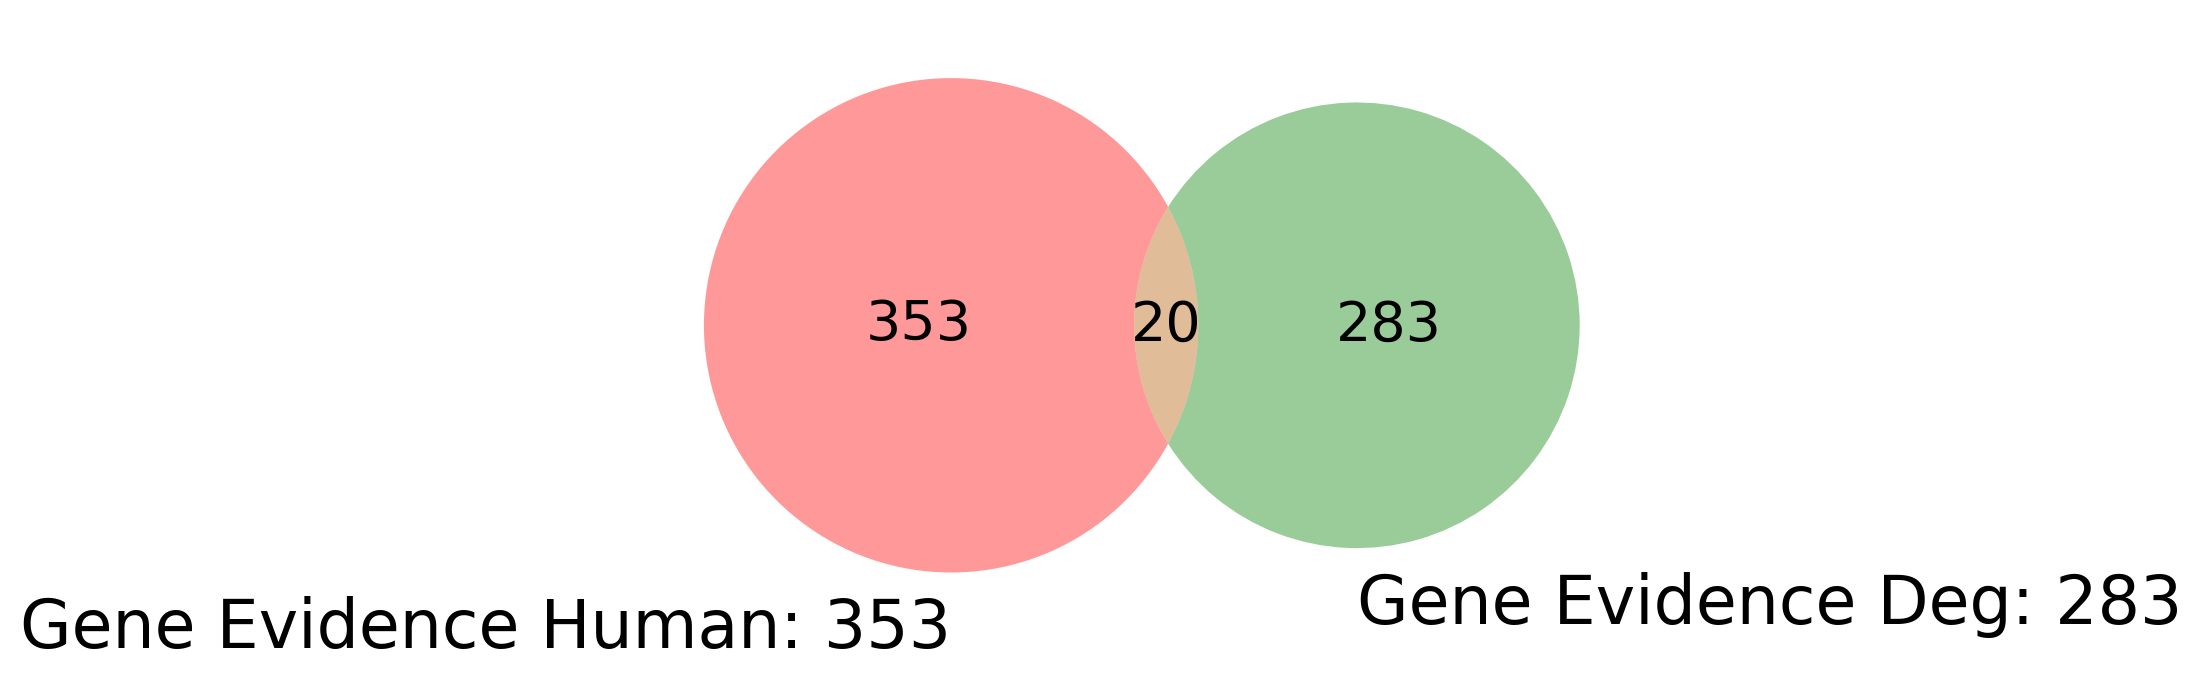

In [27]:
print(left, itx, right, itx_vals)
create_venn(left, right, itx, f'Gene Evidence Human: {left}', f'Gene Evidence Deg: {right}')

## Global Celltype Comparison

In [28]:
feature = "cell_type_label" # eventually change this to comparing based on a map we can create

first = derived_human_ev[feature].str.strip().str.upper()
second = deg_ev[feature].str.strip().str.upper()

left  = set_diff(first, second)
itx   = set_itx(first, second)
right = set_diff(second, first)
itx_vals = set_itx_vals(first, second)

373 0 303 []


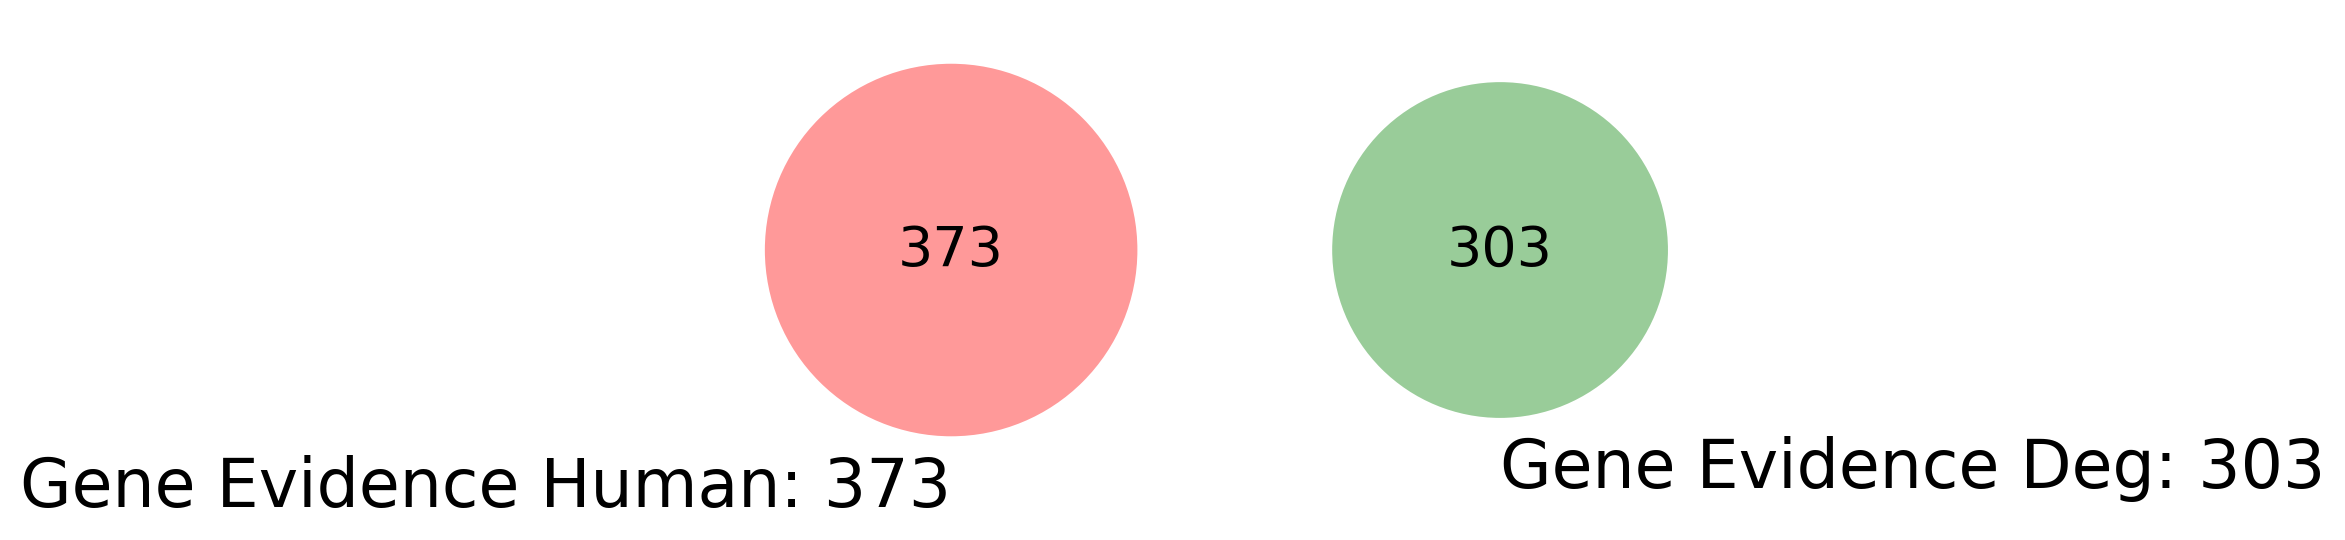

In [29]:
print(left, itx, right, itx_vals)
create_venn(left, right, itx, f'Gene Evidence Human: {left}', f'Gene Evidence Deg: {right}')

## Set Difference + Intersection of Gene Expression Between All Cells in Evidence Deg and Evidence Human

In [30]:
def make_3d_matrix(human_fn, deg_fn):
    """
    Finds similarites in gene expression between all cells mentioned in evidence deg and evidence human and returns a 3D matrix describing the left difference, intersection, and right difference in gene expression.

    Returns:
        pd.DataFrame: the 3D matrix describing set difference and intersection in gene expression
    """

    human_ev = load_human_evidence(human_fn) # gets only the derived part of evidence.json in evidence_human
    deg_ev = load_deg_evidence(deg_fn) 

    feature = "cell_type_label"

    # x axis is human evidence and y axis is deg evidence

    x_labels = sorted(human_ev[feature].unique())
    y_labels = sorted(deg_ev[feature].unique())

    result_df = pd.DataFrame(index = x_labels, columns=y_labels, dtype=object)

    for x in x_labels:
        for y in y_labels:
            genes1 = set(human_ev[human_ev[feature] == x]['gene_id'])
            genes2 = set(deg_ev[deg_ev[feature] == y]['gene_id'])

            left_diff = genes1 - genes2
            intersection = genes1 & genes2
            right_diff = genes2 - genes1

            result_df.loc[x,y] = [left_diff, intersection, right_diff]

    return result_df

In [35]:
matrix = make_3d_matrix(fn_human, fn_deg)

matrix

,ASPC,LEC,SMC,adipocyte,b_cell,dendritic_cell,endometrium,endothelial,macrophage,mast_cell,mesothelium,monocyte,neutrophil,nk_cell,pericyte,t_cell
adipocytes,"[{ENSG00000132170}, {}, {ENSG00000133083, ENSG...","[{ENSG00000132170}, {}, {ENSG00000154330, ENSG...","[{ENSG00000132170}, {}, {ENSG00000183230, ENSG...","[{}, {ENSG00000132170}, {ENSG00000213904, ENSG...","[{ENSG00000132170}, {}, {ENSG00000196092, ENSG...","[{ENSG00000132170}, {}, {ENSG00000106066, ENSG...","[{ENSG00000132170}, {}, {ENSG00000185774, ENSG...","[{ENSG00000132170}, {}, {ENSG00000101333, ENSG...","[{ENSG00000132170}, {}, {ENSG00000177575, ENSG...","[{ENSG00000132170}, {}, {ENSG00000111728, ENSG...","[{ENSG00000132170}, {}, {ENSG00000128918, gene...","[{ENSG00000132170}, {}, {ENSG00000197555, ENSG...","[{ENSG00000132170}, {}, {ENSG00000062716, ENSG...","[{ENSG00000132170}, {}, {ENSG00000185697, ENSG...","[{ENSG00000132170}, {}, {ENSG00000164465, gene...","[{ENSG00000132170}, {}, {ENSG00000134954, ENSG..."
hAD2,"[{ENSG00000062282}, {}, {ENSG00000133083, ENSG...","[{ENSG00000062282}, {}, {ENSG00000154330, ENSG...","[{ENSG00000062282}, {}, {ENSG00000183230, ENSG...","[{ENSG00000062282}, {}, {ENSG00000213904, ENSG...","[{ENSG00000062282}, {}, {ENSG00000196092, ENSG...","[{ENSG00000062282}, {}, {ENSG00000106066, ENSG...","[{ENSG00000062282}, {}, {ENSG00000185774, ENSG...","[{ENSG00000062282}, {}, {ENSG00000101333, ENSG...","[{ENSG00000062282}, {}, {ENSG00000177575, ENSG...","[{ENSG00000062282}, {}, {ENSG00000111728, ENSG...","[{ENSG00000062282}, {}, {ENSG00000128918, gene...","[{ENSG00000062282}, {}, {ENSG00000197555, ENSG...","[{ENSG00000062282}, {}, {ENSG00000062716, ENSG...","[{ENSG00000062282}, {}, {ENSG00000185697, ENSG...","[{ENSG00000062282}, {}, {ENSG00000164465, gene...","[{ENSG00000062282}, {}, {ENSG00000134954, ENSG..."
hAD3,"[{ENSG00000072310, ENSG00000100344, ENSG000000...","[{ENSG00000072310, ENSG00000100344, ENSG000000...","[{ENSG00000072310, ENSG00000100344, ENSG000000...","[{ENSG00000072310, ENSG00000100344, ENSG000000...","[{ENSG00000072310, ENSG00000100344, ENSG000000...","[{ENSG00000072310, ENSG00000100344, ENSG000000...","[{ENSG00000072310, ENSG00000100344, ENSG000000...","[{ENSG00000072310, ENSG00000100344, ENSG000000...","[{ENSG00000072310, ENSG00000100344, ENSG000000...","[{ENSG00000072310, ENSG00000100344, ENSG000000...","[{ENSG00000072310, ENSG00000100344, ENSG000000...","[{ENSG00000072310, ENSG00000100344, ENSG000000...","[{ENSG00000072310, ENSG00000100344, ENSG000000...","[{ENSG00000072310, ENSG00000100344, ENSG000000...","[{ENSG00000072310, ENSG00000100344, ENSG000000...","[{ENSG00000072310, ENSG00000100344, ENSG000000..."
hASDC,"[{ENSG00000104856, ENSG00000262418}, {}, {ENSG...","[{ENSG00000104856, ENSG00000262418}, {}, {ENSG...","[{ENSG00000104856, ENSG00000262418}, {}, {ENSG...","[{ENSG00000104856, ENSG00000262418}, {}, {ENSG...","[{ENSG00000104856, ENSG00000262418}, {}, {ENSG...","[{ENSG00000104856, ENSG00000262418}, {}, {ENSG...","[{ENSG00000104856, ENSG00000262418}, {}, {ENSG...","[{ENSG00000104856, ENSG00000262418}, {}, {ENSG...","[{ENSG00000104856, ENSG00000262418}, {}, {ENSG...","[{ENSG00000104856, ENSG00000262418}, {}, {ENSG...","[{ENSG00000104856, ENSG00000262418}, {}, {ENSG...","[{ENSG00000104856, ENSG00000262418}, {}, {ENSG...","[{ENSG00000104856, ENSG00000262418}, {}, {ENSG...","[{ENSG00000104856, ENSG00000262418}, {}, {ENSG...","[{ENSG00000104856, ENSG00000262418}, {}, {ENSG...","[{ENSG00000104856, ENSG00000262418}, {}, {ENSG..."
hASPC1,"[{ENSG00000221869, ENSG00000134853}, {}, {ENSG...","[{ENSG00000221869, ENSG00000134853}, {}, {ENSG...","[{ENSG00000221869, ENSG00000134853}, {}, {ENSG...","[{ENSG00000221869, ENSG00000134853}, {}, {ENSG...","[{ENSG00000221869, ENSG00000134853}, {}, {ENSG...","[{ENSG00000221869, ENSG00000134853}, {}, {ENSG...","[{ENSG00000221869, ENSG00000134853}, {}, {ENSG...","[{ENSG00000221869, ENSG00000134853}, {}, {ENSG...","[{ENSG00000221869, ENSG00000134853}, {}, {ENSG...","[{ENSG00000221869, ENS

## Find Cells with Similar Expression

In [60]:
def find_similar_cells():
    """
    Goes through the matrix and counts the number of intersected genes to be able to easily identify similar cells

    Returns:
        pd.DataFrame: the 3D matrix describing the count in gene expression intersection
    """
    
    intersection_df = matrix.copy()
    for index in matrix.index:
        for value in matrix.columns:
            intersection = matrix.loc[index, value][1]

            count = len(intersection)

            intersection_df.loc[index, value] = count if count > 0 else None
    
    return intersection_df


In [62]:
cell_similarity_matrix = find_similar_cells()

cell_similarity_matrix

,ASPC,LEC,SMC,adipocyte,b_cell,dendritic_cell,endometrium,endothelial,macrophage,mast_cell,mesothelium,monocyte,neutrophil,nk_cell,pericyte,t_cell
adipocytes,None,None,None,1,None,None,None,None,None,None,None,None,None,None,None,None
hAD2,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None
hAD3,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None
hASDC,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None
hASPC1,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None
hASPC2,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None
hASPC3,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None
hASPC4,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None
hASPC5,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None
hASPC6,None,None,None,None,None,None,None,None,1,None,None,None,None,None,None,None


In [65]:
def get_similar_cells():
    result = []
    for index in cell_similarity_matrix.index:
        for value in cell_similarity_matrix.columns:
            if cell_similarity_matrix.loc[index, value]:
                result.append([index, value])
    return result


In [66]:
get_similar_cells()

[['adipocytes', 'adipocyte'],
 ['hASPC6', 'macrophage'],
 ['hAd1', 'ASPC'],
 ['hAd1', 'adipocyte'],
 ['hAd1', 'mesothelium'],
 ['hAd2', 'ASPC'],
 ['hAd2', 'adipocyte'],
 ['hAd2', 'dendritic_cell'],
 ['hAd2', 'mesothelium'],
 ['hAd3', 'ASPC'],
 ['hAd3', 'adipocyte'],
 ['hAd3', 'mesothelium'],
 ['hAd4', 'ASPC'],
 ['hAd4', 'adipocyte'],
 ['hAd4', 'mesothelium'],
 ['hAd5', 'ASPC'],
 ['hAd5', 'adipocyte'],
 ['hAd5', 'mesothelium'],
 ['hAd6', 'ASPC'],
 ['hAd6', 'adipocyte'],
 ['hAd6', 'dendritic_cell'],
 ['hAd6', 'mesothelium'],
 ['hAd6', 'pericyte'],
 ['hAd7', 'ASPC'],
 ['hAd7', 'adipocyte'],
 ['hAd7', 'mesothelium'],
 ['hBcell', 'b_cell'],
 ['hEndoA1', 'endothelial'],
 ['hEndoA2', 'endothelial'],
 ['hEndoS1', 'endothelial'],
 ['hEndoS2', 'endothelial'],
 ['hEndoS3', 'endothelial'],
 ['hEndoS3', 'monocyte'],
 ['hEndoV', 'endothelial'],
 ['hLEC1', 'LEC'],
 ['hLEC1', 'endothelial'],
 ['hLEC2', 'LEC'],
 ['hLEC2', 'endothelial'],
 ['hMac2', 'neutrophil'],
 ['hMac3', 'neutrophil'],
 ['hMast', 'm